In [3]:
library(Seurat)
library(dplyr)
library(magrittr)
library(ggplot2)
library(RColorBrewer)
library(tidyr)
library(dplyr)
library(readxl)
library(stringr)
#library(DoubletFinder)
library(repr)

In [4]:
set.seed(1)
options(repr.plot.width = 12, repr.plot.height = 10)

In [5]:
load_data <- function(filename) {
    df = read.csv(paste("../data/processed_data/mutations_with_subtypes", 
                        filename, sep="/"))
    return(df)
}

In [6]:
perform_analysis <- function(df, 
                             scale,
                             normalize,
                             dim_reduction_method,
                             plot_title,
                             color_by,
                             seurat_clustering,
                             conduct_test,
                             min_mutations_per_sample,
                             save_clustered_mutations,
                             regress_out_counts,
                             harmonize=FALSE,
                             harmony_batch_var="",
                             seurat_func_args=
                               list(normalize_data_args=list(normalization.method=
                                                               "LogNormalize"),
                                    find_var_features_args=list(nfeatures=2000),
                                    scale_data_args=list(verbose=F),
                                    pca_args=list(npcs=30, approx_svd=F, verbose=F),
                                    umap_args=list(n.neighbors=30, dims=1:15, verbose=F),
                                    tsne_args=list(dims=1:15, seed=42),
                                    find_neighbors_args=list(dims=1:20),
                                    find_clusters_args=list(resolution=0.7)),
                            manually_supplied_cols=c()) {

  print("Performing Seurat analysis...")   
  normalize_data_args=seurat_func_args$normalize_data_args
  find_var_features_args = seurat_func_args$find_var_features_args
  scale_data_args = seurat_func_args$scale_data_args
  pca_args = seurat_func_args$pca_args
  umap_args = seurat_func_args$umap_args
  tsne_args = seurat_func_args$tsne_args
  find_neighbors_args = seurat_func_args$find_neighbors_args
  find_clusters_args = seurat_func_args$find_clusters_args
  
  chr_ranges = colnames(df)[grepl("chr[0-9]", colnames(df))]
  
  mutations_df = df[, grepl("chr[0-9]", colnames(df))]
  mutations_df = t(mutations_df)
  
  colnames(mutations_df) = df[["donor_id"]]
  print("Creating Seurat Object...")
  seurat_data = CreateSeuratObject(counts = mutations_df)
  
  if (!color_by == "mut_counts" && !color_by == "seurat_clusters__categorical") {
    data_color_by = df[[color_by]]
  }
  
  metadata = seurat_data@meta.data
  colnames(metadata)[grepl("nCount_RNA", colnames(metadata))] = "mut_counts"
  seurat_data@meta.data = metadata
  
  print("Adding metadata...")
  if (color_by != "seurat_clusters__categorical" && color_by != "mut_counts") {
    if (grepl("__categorical", color_by)) {
      seurat_data = AddMetaData(object = seurat_data, metadata = 
                                  data_color_by, col.name = color_by)
    } else {
      seurat_data = AddMetaData(object = seurat_data, metadata = 
                                  as.numeric(data_color_by), 
                                col.name = color_by)
    }
  }
  
  seurat_data = seurat_data[, seurat_data@meta.data$mut_counts >= min_mutations_per_sample]
  
  if (normalize) {
    print("Normalizing data...")
    seurat_data = NormalizeData(seurat_data, 
                                normalization.method = 
                                  normalize_data_args$normalization.method)
  }
  
  print("Finding Variable Features...")
  seurat_data = FindVariableFeatures(seurat_data,
                                     nfeatures=find_var_features_args$nfeatures)
  
  if (scale) {
    print("Scaling data...")
    if (regress_out_counts) {
      seurat_data = ScaleData(seurat_data, vars.to.regress = "mut_counts")
    }
    else {
      seurat_data = ScaleData(seurat_data)
    }
  }
  
  print("Running PCA...")
  seurat_data = RunPCA(seurat_data, 
                       npcs=pca_args$npcs, 
                       approx_svd=pca_args$approx_svd, 
                       verbose=pca_args$verbose)
  if (harmonize) {
      print("Harmony batch correction...")
      seurat_data <- RunHarmony(seurat_data, harmony_batch_var) 
  }

  dims_for_dim_reduction = pca_args$npcs
  if (dim_reduction_method == "umap") {
    print("Running UMAP...")
    seurat_data = RunUMAP(seurat_data, 
                          n.neighbors=umap_args$n.neighbors, 
                          dims=umap_args$dims, 
                          verbose=umap_args$verbose,
                          min.dist=umap_args$min.dist)
    dims_for_dim_reduction = umap_args$dims
  } else if (dim_reduction_method == "tsne") {
    print("Running TSNE...")
    seurat_data = RunTSNE(seurat_data, 
                          dims=tsne_args$dims)
    dims_for_dim_reduction = tsne_args$dims
  }
  
  dims_for_dim_reduction = dims_for_dim_reduction[length(dims_for_dim_reduction)]
  settings = paste0("top_", find_var_features_args$nfeatures,
                    "-",
                    "scale_", scale,
                    "-",
                    "norm_by_mut_counts_", normalize,
                    "-", 
                    "pca_n_components_", pca_args$npcs,
                    "-",
                    "dims_for_dim_reduction_", paste0("1to", dims_for_dim_reduction),
                    "-",
                    "regress_by_counts_", !is.null(scale_data_args$vars.to.regress),
                    "-",
                    "min_mutations_per_sample", min_mutations_per_sample)
  
  if (seurat_clustering) {
    print("Running FindNeighbors...")
    seurat_data = FindNeighbors(seurat_data, dims=find_neighbors_args$dims)
    print("Running FindClusters...")
    seurat_data = FindClusters(seurat_data, resolution=find_clusters_args$resolution)
    clusters = Idents(seurat_data)
    settings = paste0(settings, "_clustering_res_", find_clusters_args$resolution)
    if (save_clustered_mutations) {
      print("Saving clusters...")
      mutations_df_sep = t(as_tibble(cbind(t(as.data.frame(mutations_df)), clusters, 
                                           df[["donor_id"]])))
      mutations_df = as_tibble(cbind(t(as.data.frame(mutations_df)), clusters))
      mutations_df = mutations_df %>% 
        group_by(clusters) %>%
        summarize(across(everything(), sum)) 
      mutations_df = t(mutations_df)
      mutations_df = as_tibble(mutations_df)[2:nrow(mutations_df), ]
      clusters_names = paste("cluster", seq(from=0, to=ncol(mutations_df)-1), sep="_")
      colnames(mutations_df) = paste(plot_title, settings,
                                     clusters_names, 
                                     sep="x")
      rownames(mutations_df) = chr_ranges
      fn = paste0(settings, ".csv")
      path = paste("../data/processed_data/de_novo_seurat_clustered_mutations", 
                   plot_title, sep="/")
      fp = file.path(path, fn)
      dir.create(path, recursive=T)
      write.csv(mutations_df, fp)
      
      fn_sep = paste0(settings, "_separated.csv")
      fp_sep = file.path(path, fn_sep)
      write.csv(mutations_df_sep, fp_sep)
    }
    #         if (conduct_test) {
    #             clusters = split(clusters, names(clusters))
    #             wilcox.test(group1, group2, alternative = "two.sided", 
    #                         conf.int = TRUE)
    #         }
  }
  
  seurat_data@meta.data$mut_counts = log(seurat_data@meta.data$mut_counts, base = exp(1))
  
  if (grepl("__categorical", color_by)) {
    print(paste0("Plotting by ", gsub("__categorical", "", color_by)))
    if (color_by == "seurat_clusters__categorical") {
      color_by = "seurat_clusters"
    }
    if (length(manually_supplied_cols) != 0) {
        p = DimPlot(seurat_data, reduction = dim_reduction_method, pt.size=2.5, 
                group.by = color_by, cols=manually_supplied_cols)
    }
    else {
        viz_distinct_cols = c("#7F00FF", "#3cb44b", "#ffd8b1", "#4363d8", "#f58231",
                          "#FF0000", "#42d4f4", "#f032e6", "#bfef45", "#fabed4",
                          "#469990", "#dcbeff", "#9A6324", "#808000", "#800000",
                          "#aaffc3", "#000075", "#ffe119", "#000000")

        num_cols = length(unique(seurat_data@meta.data[[color_by]]))
        p = DimPlot(seurat_data, reduction = dim_reduction_method, pt.size=2.5, 
                group.by = color_by, cols=viz_distinct_cols[1:num_cols])

    }
#     p = DimPlot(seurat_data, reduction = dim_reduction_method, pt.size=2.5, 
#                 group.by = color_by, cols=DiscretePalette(num_cols, palette="glasbey", 
#                                                           shuffle=T))
  } 
  else {
    print("Dim Plot")
    p = FeaturePlot(seurat_data, features = color_by, 
                    shape.by=NULL, pt.size=2)
  }
  
  path = paste("..", "figures", "dim_reduced_data", "Seurat", plot_title, sep="/")
  dir.create(path, recursive=T)
  
  filename = paste0(settings,
                    "-",
                    "color_by_", color_by)
  
  filename = paste0(filename, ".png")
  
  filepath = paste(path, filename, sep="/")
  ggsave(filepath, plot = last_plot(), dpi = 300, width = 12, height = 8)
  print(p)
    return(seurat_data)
}

In [8]:
df = load_data("all_lung.csv")
df["subtype_grouped_meso"] = df["subtype"]
df = df[!(df["subtype"] == "Not.Otherwise.Specified" |  df["subtype"] == "Sarcomatoid"| 
        df["subtype"] == "Biphasic"),]
colnames(df)[1] = "donor_id"
colnames(df)[match("subtype", colnames(df))] = "subtype__categorical"
colnames(df)[match("subtype_grouped_meso", colnames(df))] = "subtype_grouped_meso__categorical"
head(df)


,donor_id,chr1.5,chr1.6,chr1.7,chr1.8,chr1.9,chr1.11,chr1.12,chr1.15,chr1.16,⋯,stage_UICC,smoking_status,smoking_history..pack.years.,chemotherapy.NEO.ADJUVANT..yes.no.,chemotherapy..yes.no.,radiation..yes.no.,Status..at.time.of.last.follow.up.,progression.free_survival..months.,overall_survival..months.,subtype_grouped_meso__categorical
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,DO25068,5,6,1,5,4,1,4,6,1,⋯,,,,,,,,NA,NA,Adeno
2,DO24130,5,2,2,3,2,1,5,4,0,⋯,,,,,,,,NA,NA,Adeno
3,DO24497,1,3,1,1,1,4,2,0,2,⋯,,,,,,,,NA,NA,Adeno
4,DO25010,27,17,12,22,3,11,24,8,13,⋯,,,,,,,,NA,NA,Adeno
5,DO24675,28,22,13,11,2,11,8,6,7,⋯,,,,,,,,NA,NA,Adeno
6,DO23687,0,0,0,1,1,0,2,1,0,⋯,,,,,,,,NA,NA,Adeno


In [8]:
#Load MSKCC
MSKCC<-data.frame(read.csv("MSKCC_Indi.csv"))
MSKCC<-data.frame(t(MSKCC))
colnames(MSKCC)<-MSKCC[1,]
MSKCC<-MSKCC[-1,]
head(MSKCC)


,chr1.5,chr1.6,chr1.7,chr1.8,chr1.9,chr1.11,chr1.12,chr1.15,chr1.16,chr1.19,⋯,chr22.34,chr22.36,chr22.37,chr22.40,chr22.41,chr22.42,chr22.43,chr22.44,chr22.45,chr22.46
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A02,1,1,3,2,1,4,2,2,2,0,⋯,0,2,1,1,0,2,1,1,2,0
A12,5,4,6,3,3,5,4,4,6,4,⋯,5,6,0,14,7,3,4,4,3,1
A15,2,0,0,0,2,0,1,2,0,1,⋯,0,2,1,3,3,1,1,2,1,2
A08,1,3,4,1,5,3,2,6,0,1,⋯,6,5,0,0,1,1,2,2,1,3
A17,11,8,6,8,7,7,5,6,5,3,⋯,2,8,1,5,5,4,5,6,5,6
A01,8,5,18,19,34,38,30,21,25,7,⋯,21,29,25,25,25,24,23,16,11,16


In [9]:
dim(MSKCC)

[1]   11 2128

In [10]:
MSKCC$donor_id<-rownames(MSKCC)
MSKCC$subtype_grouped_meso__categorical<-"MSKCC"
head(MSKCC)


,chr1.5,chr1.6,chr1.7,chr1.8,chr1.9,chr1.11,chr1.12,chr1.15,chr1.16,chr1.19,⋯,chr22.37,chr22.40,chr22.41,chr22.42,chr22.43,chr22.44,chr22.45,chr22.46,donor_id,subtype_grouped_meso__categorical
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A02,1,1,3,2,1,4,2,2,2,0,⋯,1,1,0,2,1,1,2,0,A02,MSKCC
A12,5,4,6,3,3,5,4,4,6,4,⋯,0,14,7,3,4,4,3,1,A12,MSKCC
A15,2,0,0,0,2,0,1,2,0,1,⋯,1,3,3,1,1,2,1,2,A15,MSKCC
A08,1,3,4,1,5,3,2,6,0,1,⋯,0,0,1,1,2,2,1,3,A08,MSKCC
A17,11,8,6,8,7,7,5,6,5,3,⋯,1,5,5,4,5,6,5,6,A17,MSKCC
A01,8,5,18,19,34,38,30,21,25,7,⋯,25,25,25,24,23,16,11,16,A01,MSKCC


In [11]:
colnames(MSKCC)

[1] "chr1.5"                            "chr1.6"                           
   [3] "chr1.7"                            "chr1.8"                           
   [5] "chr1.9"                            "chr1.11"                          
   [7] "chr1.12"                           "chr1.15"                          
   [9] "chr1.16"                           "chr1.19"                          
  [11] "chr1.20"                           "chr1.21"                          
  [13] "chr1.23"                           "chr1.24"                          
  [15] "chr1.25"                           "chr1.31"                          
  [17] "chr1.32"                           "chr1.33"                          
  [19] "chr1.34"                           "chr1.35"                          
  [21] "chr1.36"                           "chr1.37"                          
  [23] "chr1.38"                           "chr1.39"                          
  [25] "chr1.42"                           "chr1.43"                          
  [27] "chr1.44"                           "chr1.45"                          
  [29] "chr1.49"                           "chr1.51"                          
  [31] "chr1.52"                           "chr1.53"                          
  [33] "chr1.54"                           "chr1.55"                          
  [35] "chr1.56"                           "chr1.57"                          
  [37] "chr1.58"                           "chr1.60"                          
  [39] "chr1.61"                           "chr1.62"                          
  [41] "chr1.63"                           "chr1.64"                          
  [43] "chr1.65"                           "chr1.66"                          
  [45] "chr1.67"                           "chr1.68"                          
  [47] "chr1.69"                           "chr1.70"                          
  [49] "chr1.71"                           "chr1.72"                          
  [51] "chr1.73"                           "chr1.74"                          
  [53] "chr1.75"                           "chr1.76"                          
  [55] "chr1.77"                           "chr1.78"                          
  [57] "chr1.79"                           "chr1.80"                          
  [59] "chr1.81"                           "chr1.82"                          
  [61] "chr1.83"                           "chr1.85"                          
  [63] "chr1.86"                           "chr1.87"                          
  [65] "chr1.88"                           "chr1.89"                          
  [67] "chr1.90"                           "chr1.91"                          
  [69] "chr1.92"                           "chr1.93"                          
  [71] "chr1.95"                           "chr1.96"                          
  [73] "chr1.97"                           "chr1.98"                          
  [75] "chr1.99"                           "chr1.100"                         
  [77] "chr1.101"                          "chr1.102"                         
  [79] "chr1.103"                          "chr1.106"                         
  [81] "chr1.107"                          "chr1.108"                         
  [83] "chr1.110"                          "chr1.111"                         
  [85] "chr1.112"                          "chr1.113"                         
  [87] "chr1.115"                          "chr1.116"                         
  [89] "chr1.117"                          "chr1.118"                         
  [91] "chr1.119"                          "chr1.120"                         
  [93] "chr1.149"                          "chr1.150"                         
  [95] "chr1.152"                          "chr1.154"                         
  [97] "chr1.155"                          "chr1.156"                         
  [99] "chr1.157"                          "chr1.160"                         
 [101] "chr1.161"                          "chr1.162"

In [12]:
# Identify the column names you want based on df
colsaa <- names(df)

# For any columns in df but missing in MSKCC, add them to MSKCC as NA (or you can use "" if you prefer blanks)
missing_cols <- setdiff(colsaa, names(MSKCC))
if(length(missing_cols) > 0) {
  MSKCC[missing_cols] <- NA  # change to "" if you want blank strings instead
}

# Now subset MSKCC to only the columns in df (and in the same order)
MSKCC_aligned <- MSKCC[, colsaa]

# Finally, row-bind the data frames
combined_df <- rbind(df, MSKCC_aligned)

In [11]:
tail(combined_df)

,donor_id,chr1.5,chr1.6,chr1.7,chr1.8,chr1.9,chr1.11,chr1.12,chr1.15,chr1.16,⋯,stage_UICC,smoking_status,smoking_history..pack.years.,chemotherapy.NEO.ADJUVANT..yes.no.,chemotherapy..yes.no.,radiation..yes.no.,Status..at.time.of.last.follow.up.,progression.free_survival..months.,overall_survival..months.,subtype_grouped_meso__categorical
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
A01,A01,8,5,18,19,34,38,30,21,25,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,MSKCC
A07,A07,105,73,84,78,76,101,100,126,118,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,MSKCC
A03,A03,0,1,0,3,3,0,1,0,0,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,MSKCC
A16,A16,3,4,5,2,0,0,1,4,3,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,MSKCC
A14,A14,11,12,3,8,3,2,6,8,4,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,MSKCC
A20,A20,7,5,15,15,10,10,7,8,9,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,MSKCC


In [13]:
#Using literature Metadata SCLC_Meta_Subtype.tsv
SCLCmeta<-data.frame(read.table("supplementary_files/SCLC_Meta_Subtype.tsv",header=T))
head(SCLCmeta)

SCLCA<-SCLCmeta[which(SCLCmeta$Subtype=="SCLC-A"),"ID"]
SCLCN<-SCLCmeta[which(SCLCmeta$Subtype=="SCLC-N"),"ID"]
SCLCP<-SCLCmeta[which(SCLCmeta$Subtype=="SCLC-P"),"ID"]
SCLCY<-SCLCmeta[which(SCLCmeta$Subtype=="SCLC-Y"),"ID"]


,ID,Subtype,Neuroendocrine
,<chr>,<chr>,<chr>
1,S00022,SCLC-A,NE
2,S00035,SCLC-A,NE
3,S00825,SCLC-A,NE
4,S00829,SCLC-P,non-NE
5,S00832,SCLC-A,NE
6,S00838,SCLC-A,NE


In [14]:
table(SCLCmeta$Subtype)


SCLC-A SCLC-N SCLC-P SCLC-Y 
    38      5      7      2 

In [15]:
SCLCmeta[which(SCLCmeta$Subtype=="SCLC-N"),]

,ID,Subtype,Neuroendocrine
,<chr>,<chr>,<chr>
14,S01873,SCLC-N,NE
17,S02139,SCLC-N,NE
18,S02163,SCLC-N,NE
37,S02293,SCLC-N,NE
38,S02294,SCLC-N,NE


In [16]:


combined_df$SCLC_subtype__categorical<-"NA"
combined_df[which(combined_df$donor_id %in% SCLCA),"SCLC_subtype__categorical"]<-"SCLC-A"
combined_df[which(combined_df$donor_id %in% SCLCN),"SCLC_subtype__categorical"]<-"SCLC-N"
combined_df[which(combined_df$donor_id %in% SCLCP),"SCLC_subtype__categorical"]<-"SCLC-P"
combined_df[which(combined_df$donor_id %in% SCLCY),"SCLC_subtype__categorical"]<-"SCLC-Y"
combined_df[which(combined_df$donor_id %in% MSKCC_aligned$donor_id),"SCLC_subtype__categorical"]<-"MSKCC"
table(combined_df$SCLC_subtype__categorical)



 MSKCC     NA SCLC-A SCLC-N SCLC-P SCLC-Y 
    11    189     37      4      6      1 

In [17]:
table(combined_df$subtype_grouped_meso__categorical)



      Adeno Epithelioid       MSKCC        SCLC    Squamous 
         37          44          11         109          47 

[1] "Performing Seurat analysis..."
[1] "Creating Seurat Object..."
[1] "Adding metadata..."
[1] "Normalizing data..."
[1] "Finding Variable Features..."
[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Running UMAP..."


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


[1] "Plotting by SCLC_subtype"


Warning message in dir.create(path, recursive = T):
“'../figures/dim_reduced_data/Seurat/all_lung_literature_Annotation' already exists”


An object of class Seurat 
2128 features across 248 samples within 1 assay 
Active assay: RNA (2128 features, 2128 variable features)
 2 dimensional reductions calculated: pca, umap

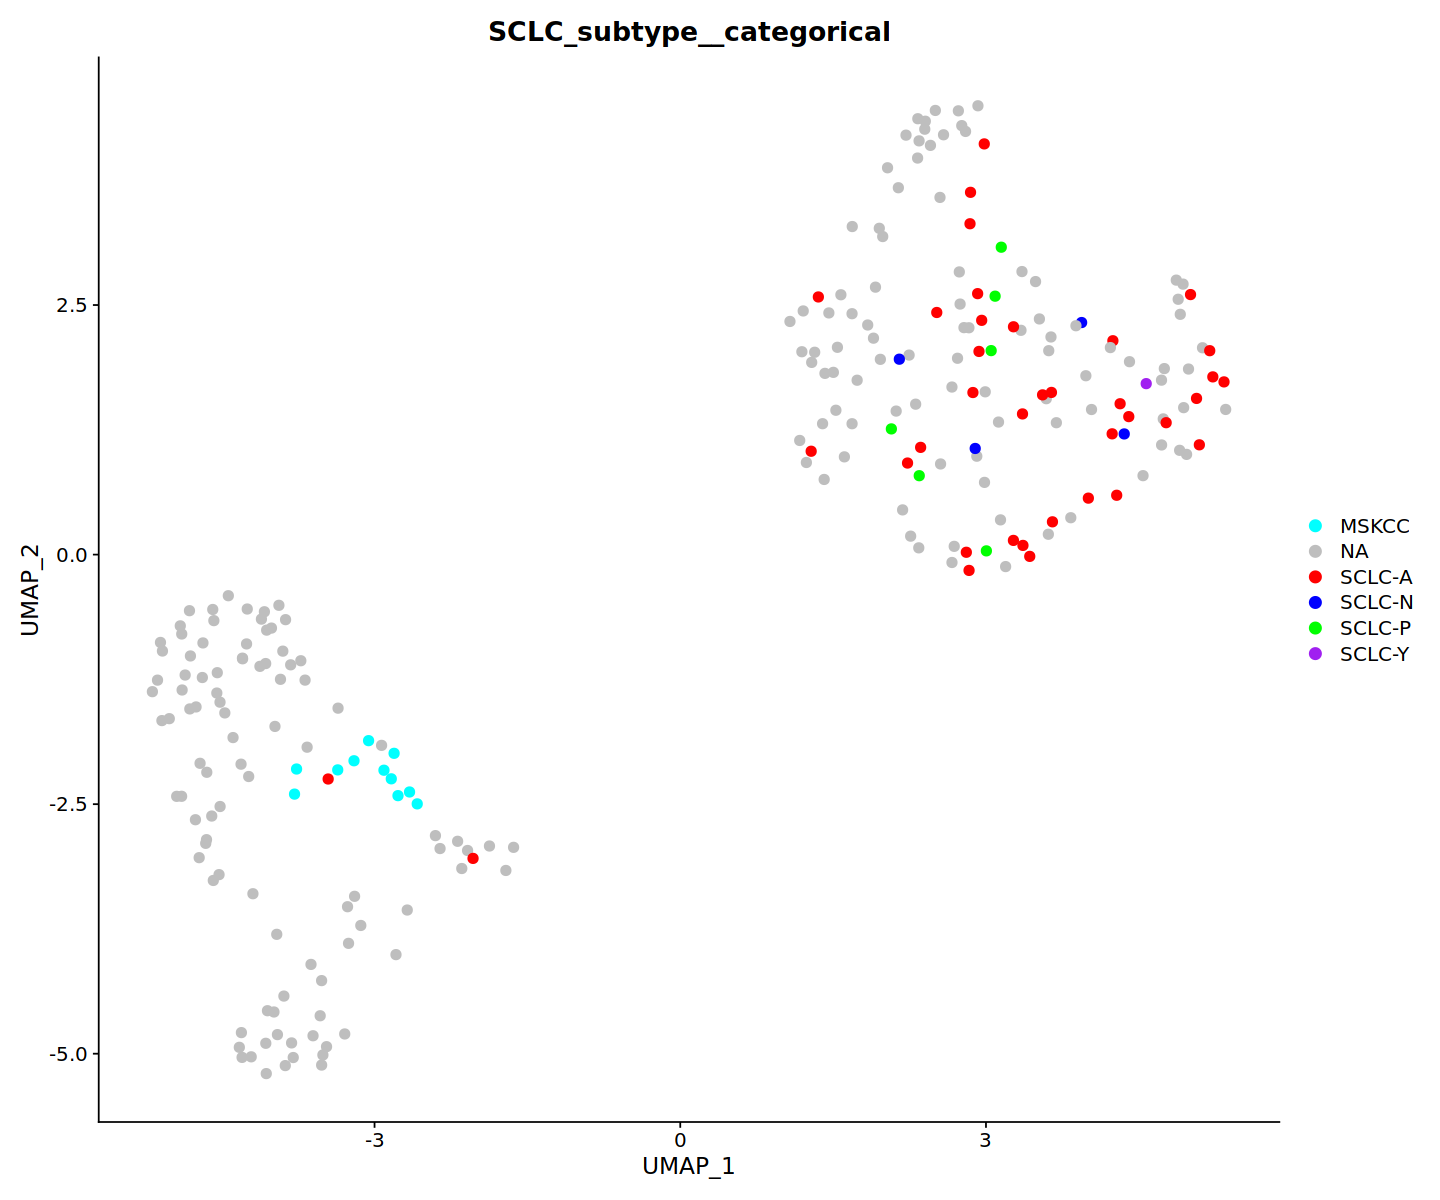

In [18]:
perform_analysis(combined_df, 
                 scale=T,
                 normalize=T,
                 dim_reduction_method="umap",
                 plot_title="all_lung_literature_Annotation",
                 color_by="SCLC_subtype__categorical",
                 seurat_clustering=F,
                 conduct_test=F,
                 min_mutations_per_sample=0,
                 save_clustered_mutations=F,
                 regress_out_counts = F,
                 seurat_func_args=
                   list(normalize_data_args=list(normalization.method=
                                                   "LogNormalize"),
                        find_var_features_args=list(nfeatures=2128),
                        scale_data_args=list(verbose=F),
                        pca_args=list(npcs=30, approx_svd=F, verbose=F),
                        umap_args=list(n.neighbors=30, dims=1:15, verbose=F, min.dist=0.2),
                        tsne_args=list(dims=2:15),
                        find_neighbors_args=list(dims=1:20),
                        find_clusters_args=list(resolution=0.7)),
                manually_supplied_cols = c("cyan","grey", "red", "blue", "green","purple"))

[1] "Performing Seurat analysis..."
[1] "Creating Seurat Object..."
[1] "Adding metadata..."
[1] "Normalizing data..."
[1] "Finding Variable Features..."
[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Running UMAP..."
[1] "Plotting by Chromothripsis"


Warning message in dir.create(path, recursive = T):
“'../figures/dim_reduced_data/Seurat/SCLC' already exists”


An object of class Seurat 
2128 features across 248 samples within 1 assay 
Active assay: RNA (2128 features, 2128 variable features)
 2 dimensional reductions calculated: pca, umap

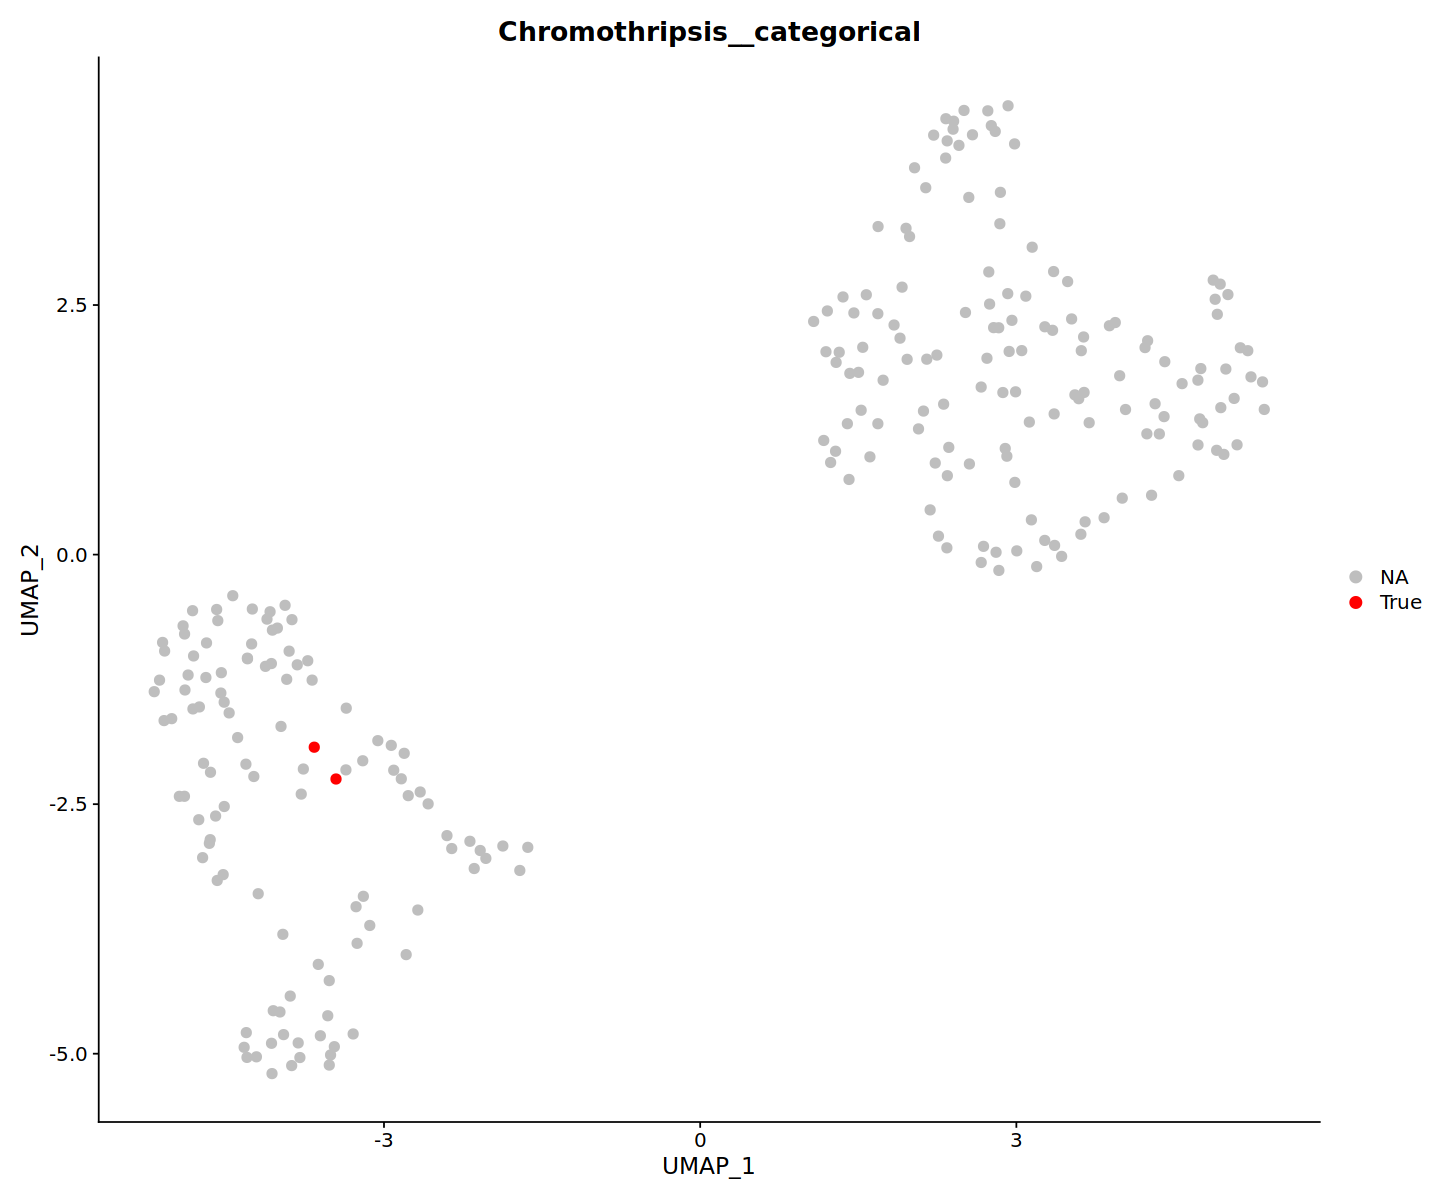

In [19]:
#Using Chromothripsis
combined_df$Chromothripsis__categorical<-"NA"
combined_df[which(combined_df$donor_id%in% c("S02353","S02297")),"Chromothripsis__categorical"]<-"True"

perform_analysis(combined_df, 
                 scale=T,
                 normalize=T,
                 dim_reduction_method="umap",
                 plot_title="SCLC",
                 color_by="Chromothripsis__categorical",
                 seurat_clustering=F,
                 conduct_test=F,
                 min_mutations_per_sample=0,
                 save_clustered_mutations=F,
                 regress_out_counts = F,
                 seurat_func_args=
                   list(normalize_data_args=list(normalization.method=
                                                   "LogNormalize"),
                        find_var_features_args=list(nfeatures=2128),
                        scale_data_args=list(verbose=F),
                        pca_args=list(npcs=30, approx_svd=F, verbose=F),
                        umap_args=list(n.neighbors=30, dims=1:15, verbose=F, min.dist=0.2),
                        tsne_args=list(dims=2:15),
                        find_neighbors_args=list(dims=1:20),
                        find_clusters_args=list(resolution=0.7)),
               manually_supplied_cols = c("grey", "red"))



[1] "Performing Seurat analysis..."
[1] "Creating Seurat Object..."
[1] "Adding metadata..."
[1] "Normalizing data..."
[1] "Finding Variable Features..."
[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Running UMAP..."
[1] "Plotting by Chromothripsis"


Warning message in dir.create(path, recursive = T):
“'../figures/dim_reduced_data/Seurat/SCLC' already exists”


An object of class Seurat 
2128 features across 248 samples within 1 assay 
Active assay: RNA (2128 features, 2128 variable features)
 2 dimensional reductions calculated: pca, umap

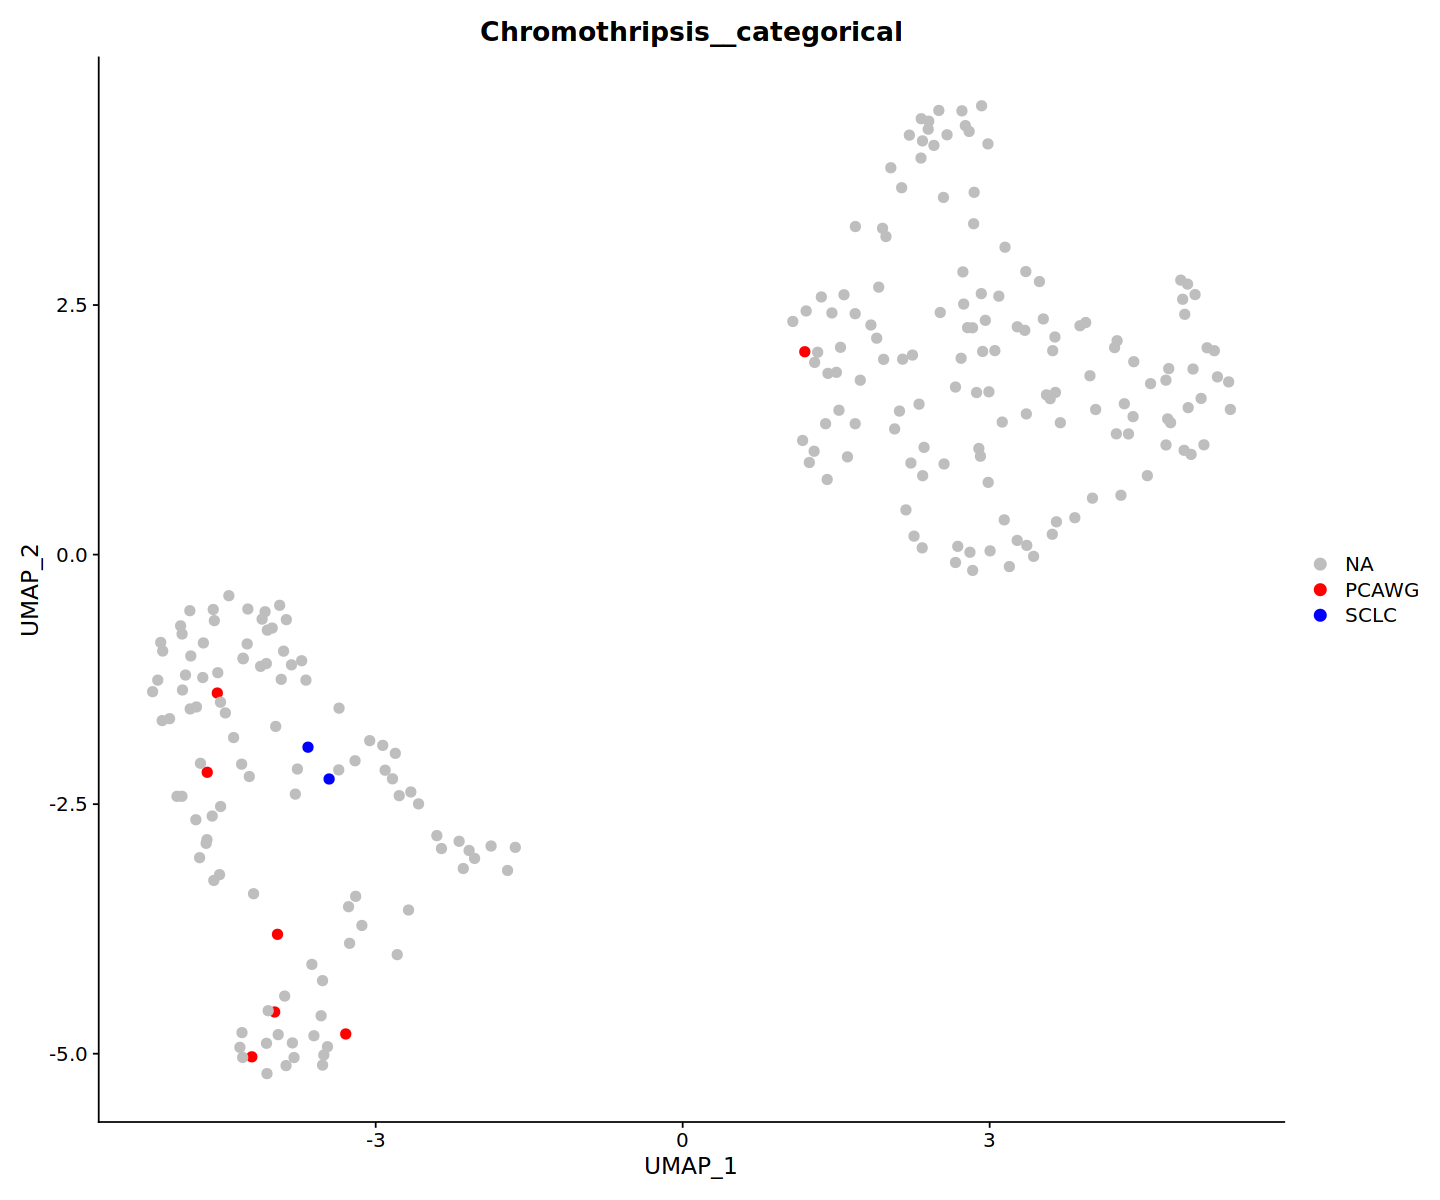

In [20]:
#Using Chromothripsis PCAWG & SCLC
combined_df$Chromothripsis__categorical<-"NA"
combined_df[which(combined_df$donor_id%in% c("DO23651","DO25985","DO25444","DO23584","DO24307","DO23687","DO26769")),"Chromothripsis__categorical"]<-"PCAWG"
combined_df[which(combined_df$donor_id%in% c("S02353","S02297")),"Chromothripsis__categorical"]<-"SCLC"



perform_analysis(combined_df, 
                 scale=T,
                 normalize=T,
                 dim_reduction_method="umap",
                 plot_title="SCLC",
                 color_by="Chromothripsis__categorical",
                 seurat_clustering=F,
                 conduct_test=F,
                 min_mutations_per_sample=0,
                 save_clustered_mutations=F,
                 regress_out_counts = F,
                 seurat_func_args=
                   list(normalize_data_args=list(normalization.method=
                                                   "LogNormalize"),
                        find_var_features_args=list(nfeatures=2128),
                        scale_data_args=list(verbose=F),
                        pca_args=list(npcs=30, approx_svd=F, verbose=F),
                        umap_args=list(n.neighbors=30, dims=1:15, verbose=F, min.dist=0.2),
                        tsne_args=list(dims=2:15),
                        find_neighbors_args=list(dims=1:20),
                        find_clusters_args=list(resolution=0.7)),
               manually_supplied_cols = c("grey", "red","blue"))



In [21]:
#Makeing Chromothripsis PCAWG mutation data
Chromothrip.PCAWG.df<-combined_df[which(combined_df$Chromothripsis__categorical=="PCAWG"),]




  chr_ranges = colnames(Chromothrip.PCAWG.df)[grepl("chr[0-9]", colnames(df))]
  
  mutations_Chromothrip.PCAWG.df= Chromothrip.PCAWG.df[, grepl("chr[0-9]", colnames(df))]
mutations_Chromothrip.PCAWG.df<-mutations_Chromothrip.PCAWG.df[,c(-(ncol(mutations_Chromothrip.PCAWG.df)-1),-(ncol(mutations_Chromothrip.PCAWG.df)))]

rownames(mutations_Chromothrip.PCAWG.df)<-Chromothrip.PCAWG.df$donor_id
  mutations_Chromothrip.PCAWG.df = t(mutations_Chromothrip.PCAWG.df)

rownames(mutations_Chromothrip.PCAWG.df)


[1] "chr1.5"    "chr1.6"    "chr1.7"    "chr1.8"    "chr1.9"    "chr1.11"  
   [7] "chr1.12"   "chr1.15"   "chr1.16"   "chr1.19"   "chr1.20"   "chr1.21"  
  [13] "chr1.23"   "chr1.24"   "chr1.25"   "chr1.31"   "chr1.32"   "chr1.33"  
  [19] "chr1.34"   "chr1.35"   "chr1.36"   "chr1.37"   "chr1.38"   "chr1.39"  
  [25] "chr1.42"   "chr1.43"   "chr1.44"   "chr1.45"   "chr1.49"   "chr1.51"  
  [31] "chr1.52"   "chr1.53"   "chr1.54"   "chr1.55"   "chr1.56"   "chr1.57"  
  [37] "chr1.58"   "chr1.60"   "chr1.61"   "chr1.62"   "chr1.63"   "chr1.64"  
  [43] "chr1.65"   "chr1.66"   "chr1.67"   "chr1.68"   "chr1.69"   "chr1.70"  
  [49] "chr1.71"   "chr1.72"   "chr1.73"   "chr1.74"   "chr1.75"   "chr1.76"  
  [55] "chr1.77"   "chr1.78"   "chr1.79"   "chr1.80"   "chr1.81"   "chr1.82"  
  [61] "chr1.83"   "chr1.85"   "chr1.86"   "chr1.87"   "chr1.88"   "chr1.89"  
  [67] "chr1.90"   "chr1.91"   "chr1.92"   "chr1.93"   "chr1.95"   "chr1.96"  
  [73] "chr1.97"   "chr1.98"   "chr1.99"   "chr1.100"  "chr1.101"  "chr1.102" 
  [79] "chr1.103"  "chr1.106"  "chr1.107"  "chr1.108"  "chr1.110"  "chr1.111" 
  [85] "chr1.112"  "chr1.113"  "chr1.115"  "chr1.116"  "chr1.117"  "chr1.118" 
  [91] "chr1.119"  "chr1.120"  "chr1.149"  "chr1.150"  "chr1.152"  "chr1.154" 
  [97] "chr1.155"  "chr1.156"  "chr1.157"  "chr1.160"  "chr1.161"  "chr1.162" 
 [103] "chr1.164"  "chr1.165"  "chr1.166"  "chr1.167"  "chr1.168"  "chr1.169" 
 [109] "chr1.170"  "chr1.172"  "chr1.173"  "chr1.174"  "chr1.175"  "chr1.177" 
 [115] "chr1.178"  "chr1.179"  "chr1.180"  "chr1.181"  "chr1.182"  "chr1.183" 
 [121] "chr1.184"  "chr1.185"  "chr1.186"  "chr1.187"  "chr1.188"  "chr1.189" 
 [127] "chr1.190"  "chr1.191"  "chr1.192"  "chr1.193"  "chr1.195"  "chr1.196" 
 [133] "chr1.197"  "chr1.198"  "chr1.200"  "chr1.201"  "chr1.202"  "chr1.204" 
 [139] "chr1.206"  "chr1.207"  "chr1.208"  "chr1.209"  "chr1.210"  "chr1.211" 
 [145] "chr1.212"  "chr1.213"  "chr1.214"  "chr1.215"  "chr1.216"  "chr1.217" 
 [151] "chr1.218"  "chr1.219"  "chr1.222"  "chr1.223"  "chr1.224"  "chr1.225" 
 [157] "chr1.227"  "chr1.228"  "chr1.229"  "chr1.230"  "chr1.231"  "chr1.233" 
 [163] "chr1.234"  "chr1.235"  "chr1.236"  "chr1.237"  "chr1.238"  "chr1.241" 
 [169] "chr1.242"  "chr1.243"  "chr10.2"   "chr10.3"   "chr10.4"   "chr10.5"  
 [175] "chr10.7"   "chr10.8"   "chr10.9"   "chr10.10"  "chr10.11"  "chr10.12" 
 [181] "chr10.14"  "chr10.15"  "chr10.16"  "chr10.17"  "chr10.20"  "chr10.21" 
 [187] "chr10.22"  "chr10.23"  "chr10.24"  "chr10.25"  "chr10.26"  "chr10.27" 
 [193] "chr10.28"  "chr10.29"  "chr10.30"  "chr10.31"  "chr10.32"  "chr10.34" 
 [199] "chr10.35"  "chr10.36"  "chr10.37"  "chr10.41"  "chr10.42"  "chr10.51" 
 [205] "chr10.52"  "chr10.53"  "chr10.55"  "chr10.56"  "chr10.57"  "chr10.58" 
 [211] "chr10.59"  "chr10.60"  "chr10.61"  "chr10.62"  "chr10.63"  "chr10.64" 
 [217] "chr10.65"  "chr10.69"  "chr10.70"  "chr10.71"  "chr10.74"  "chr10.75" 
 [223] "chr10.76"  "chr10.77"  "chr10.78"  "chr10.80"  "chr10.81"  "chr10.82" 
 [229] "chr10.83"  "chr10.84"  "chr10.85"  "chr10.87"  "chr10.88"  "chr10.89" 
 [235] "chr10.90"  "chr10.92"  "chr10.93"  "chr10.95"  "chr10.96"  "chr10.97" 
 [241] "chr10.100" "chr10.101" "chr10.103" "chr10.104" "chr10.105" "chr10.106"
 [247] "chr10.107" "chr10.108" "chr10.109" "chr10.110" "chr10.111" "chr10.112"
 [253] "chr10.113" "chr10.114" "chr10.115" "chr10.116" "chr10.117" "chr10.118"
 [259] "chr10.119" "chr10.120" "chr10.121" "chr10.122" "chr10.123" "chr10.124"
 [265] "chr10.125" "chr10.127" "chr10.128" "chr10.129" "chr10.130" "chr10.132"
 [271] "chr11.3"   "chr11.6"   "chr11.7"   "chr11.8"   "chr11.9"   "chr11.11" 
 [277] "chr11.12"  "chr11.13"  "chr11.14"  "chr11.16"  "chr11.17"  "chr11.18" 
 [283] "chr11.20"  "chr11.21"  "chr11.22"  "chr11.23"  "chr11.24"  "chr11.25" 
 [289] "chr11.26"  "chr11.27"  "chr11.28"  "chr11.29"  "chr11.30"  "chr11.31" 
 [295] "chr11.32"  "chr11.33"  "chr11.34"  "chr11.35"  "chr11.36"  "chr11.37" 
 [301] "chr11.38"  "chr11.39"  "chr11.40"  "chr11.41"

In [22]:

num_matrix <- apply(mutations_Chromothrip.PCAWG.df, 2, as.numeric)
num_matrix<-data.frame(num_matrix)
# Now calculate and add the row sums as a new column
num_matrix$rowsum <- rowSums(num_matrix)

# Check the result
head(num_matrix)
#head(mutations_Chromothrip.SCLC.df)
summutations_mutations_Chromothrip.PCAWG.df<-data.frame(num_matrix$rowsum)
rownames(summutations_mutations_Chromothrip.PCAWG.df)<-row.names(mutations_Chromothrip.PCAWG.df)
colnames(summutations_mutations_Chromothrip.PCAWG.df)<-c("ChromoPCAWG")
head(summutations_mutations_Chromothrip.PCAWG.df)

,DO23687,DO25985,DO23651,DO25444,DO24307,DO23584,DO26769,rowsum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0,41,2,38,7,10,24,122
2,0,41,0,21,7,9,27,105
3,0,15,0,6,6,3,8,38
4,1,18,0,17,3,2,19,60
5,1,10,1,6,1,3,8,30
6,0,12,0,7,5,1,11,36


,ChromoPCAWG
,<dbl>
chr1.5,122
chr1.6,105
chr1.7,38
chr1.8,60
chr1.9,30
chr1.11,36


In [23]:
SCLC.df <- combined_df[combined_df$subtype_grouped_meso__categorical %in% c("MSKCC", "SCLC"), ]
dim(SCLC.df)
head(SCLC.df)
tail(SCLC.df)

[1]  120 2149

,donor_id,chr1.5,chr1.6,chr1.7,chr1.8,chr1.9,chr1.11,chr1.12,chr1.15,chr1.16,⋯,smoking_history..pack.years.,chemotherapy.NEO.ADJUVANT..yes.no.,chemotherapy..yes.no.,radiation..yes.no.,Status..at.time.of.last.follow.up.,progression.free_survival..months.,overall_survival..months.,subtype_grouped_meso__categorical,SCLC_subtype__categorical,Chromothripsis__categorical
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
85,S00830,13,14,6,8,5,7,10,10,3,⋯,70,no,yes,yes,alive,39,58,SCLC,NA,NA
86,S02378,8,9,2,5,4,1,3,8,4,⋯,100,no,yes,yes,alive,NA,34,SCLC,SCLC-A,NA
87,S02299,79,68,40,31,14,22,38,14,22,⋯,50,no,yes,yes,alive,NA,65,SCLC,NA,NA
88,S02219,14,17,11,10,4,9,9,11,8,⋯,,,,,,NA,NA,SCLC,NA,NA
89,S02328,32,25,3,15,11,5,13,11,11,⋯,80,no,yes,yes,alive,NA,34,SCLC,SCLC-A,NA
90,S02355,3,1,2,6,2,1,1,6,1,⋯,48,no,yes,no,alive,NA,55,SCLC,NA,NA


,donor_id,chr1.5,chr1.6,chr1.7,chr1.8,chr1.9,chr1.11,chr1.12,chr1.15,chr1.16,⋯,smoking_history..pack.years.,chemotherapy.NEO.ADJUVANT..yes.no.,chemotherapy..yes.no.,radiation..yes.no.,Status..at.time.of.last.follow.up.,progression.free_survival..months.,overall_survival..months.,subtype_grouped_meso__categorical,SCLC_subtype__categorical,Chromothripsis__categorical
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
A01,A01,8,5,18,19,34,38,30,21,25,⋯,NA,NA,NA,NA,NA,NA,NA,MSKCC,MSKCC,NA
A07,A07,105,73,84,78,76,101,100,126,118,⋯,NA,NA,NA,NA,NA,NA,NA,MSKCC,MSKCC,NA
A03,A03,0,1,0,3,3,0,1,0,0,⋯,NA,NA,NA,NA,NA,NA,NA,MSKCC,MSKCC,NA
A16,A16,3,4,5,2,0,0,1,4,3,⋯,NA,NA,NA,NA,NA,NA,NA,MSKCC,MSKCC,NA
A14,A14,11,12,3,8,3,2,6,8,4,⋯,NA,NA,NA,NA,NA,NA,NA,MSKCC,MSKCC,NA
A20,A20,7,5,15,15,10,10,7,8,9,⋯,NA,NA,NA,NA,NA,NA,NA,MSKCC,MSKCC,NA


In [24]:
unique(df["subtype_grouped_meso__categorical"])

,subtype_grouped_meso__categorical
,<chr>
1,Adeno
38,Squamous
85,SCLC
194,Epithelioid


In [26]:
###Add aSCLC (Natasha et al), aSCLC (George et al) 

SCLC.df[which(SCLC.df$donor_id%in% c("S02353","S02297")),"SCLC_subtype__categorical"]<-"aSCLC(Geroge et al)"
SCLC.df[which(SCLC.df$SCLC_subtype__categorical == "MSKCC"),"SCLC_subtype__categorical"]<-"aSCLC(Natasha et al)"




In [29]:
table(SCLC.df$SCLC_subtype__categorical)


 aSCLC(Geroge et al) aSCLC(Natasha et al)                   NA 
                   2                   11                   60 
              SCLC-A               SCLC-N               SCLC-P 
                  36                    4                    6 
              SCLC-Y 
                   1 

[1] "Performing Seurat analysis..."
[1] "Creating Seurat Object..."
[1] "Adding metadata..."
[1] "Normalizing data..."
[1] "Finding Variable Features..."
[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Running UMAP..."
[1] "Plotting by SCLC_subtype"


Warning message in dir.create(path, recursive = T):
“'../figures/dim_reduced_data/Seurat/SCLC' already exists”


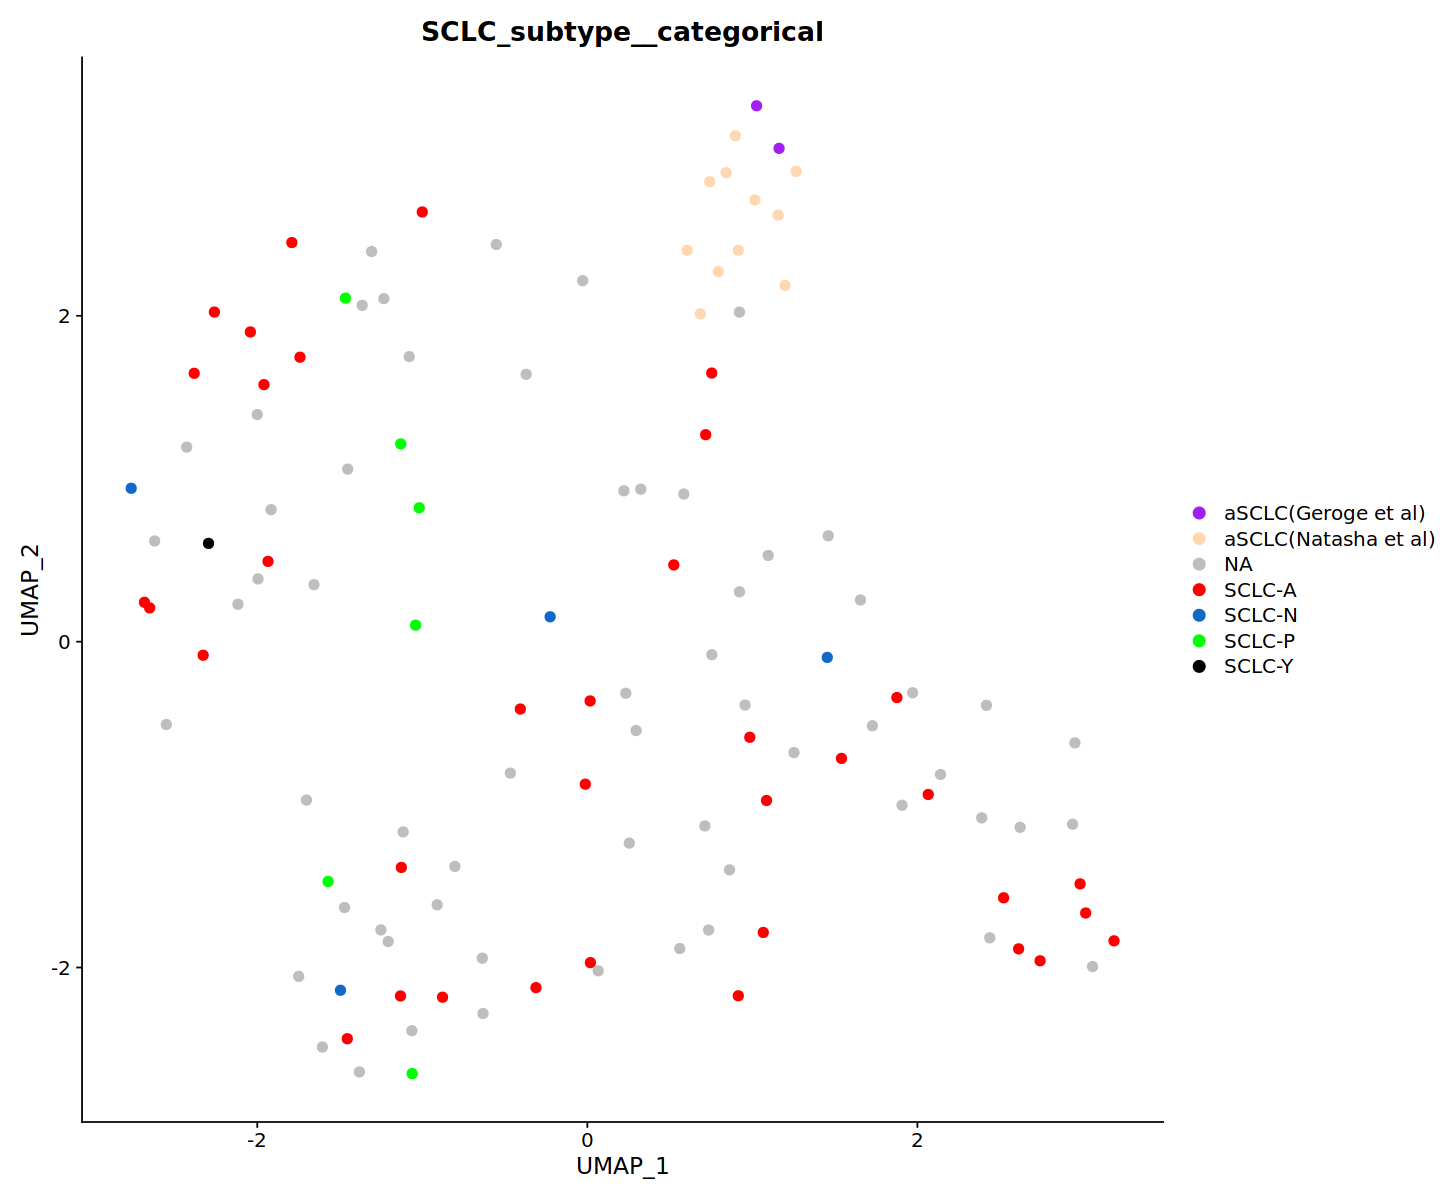

In [30]:
#Using Own Annotation
srt.SCLC<-perform_analysis(SCLC.df, 
                 scale=T,
                 normalize=T,
                 dim_reduction_method="umap",
                 plot_title="SCLC",
                 color_by="SCLC_subtype__categorical",
                 seurat_clustering=F,
                 conduct_test=F,
                 min_mutations_per_sample=0,
                 save_clustered_mutations=F,
                 regress_out_counts = F,
                 seurat_func_args=
                   list(normalize_data_args=list(normalization.method=
                                                   "LogNormalize"),
                        find_var_features_args=list(nfeatures=2128),
                        scale_data_args=list(verbose=F),
                        pca_args=list(npcs=30, approx_svd=F, verbose=F),
                        umap_args=list(n.neighbors=30, dims=1:15, verbose=F, min.dist=0.2),
                        tsne_args=list(dims=2:15),
                        find_neighbors_args=list(dims=1:20),
                        find_clusters_args=list(resolution=0.7)),
                manually_supplied_cols = c("purple","#FFD8B1","grey", "red", "#1068C9", "green","black"))

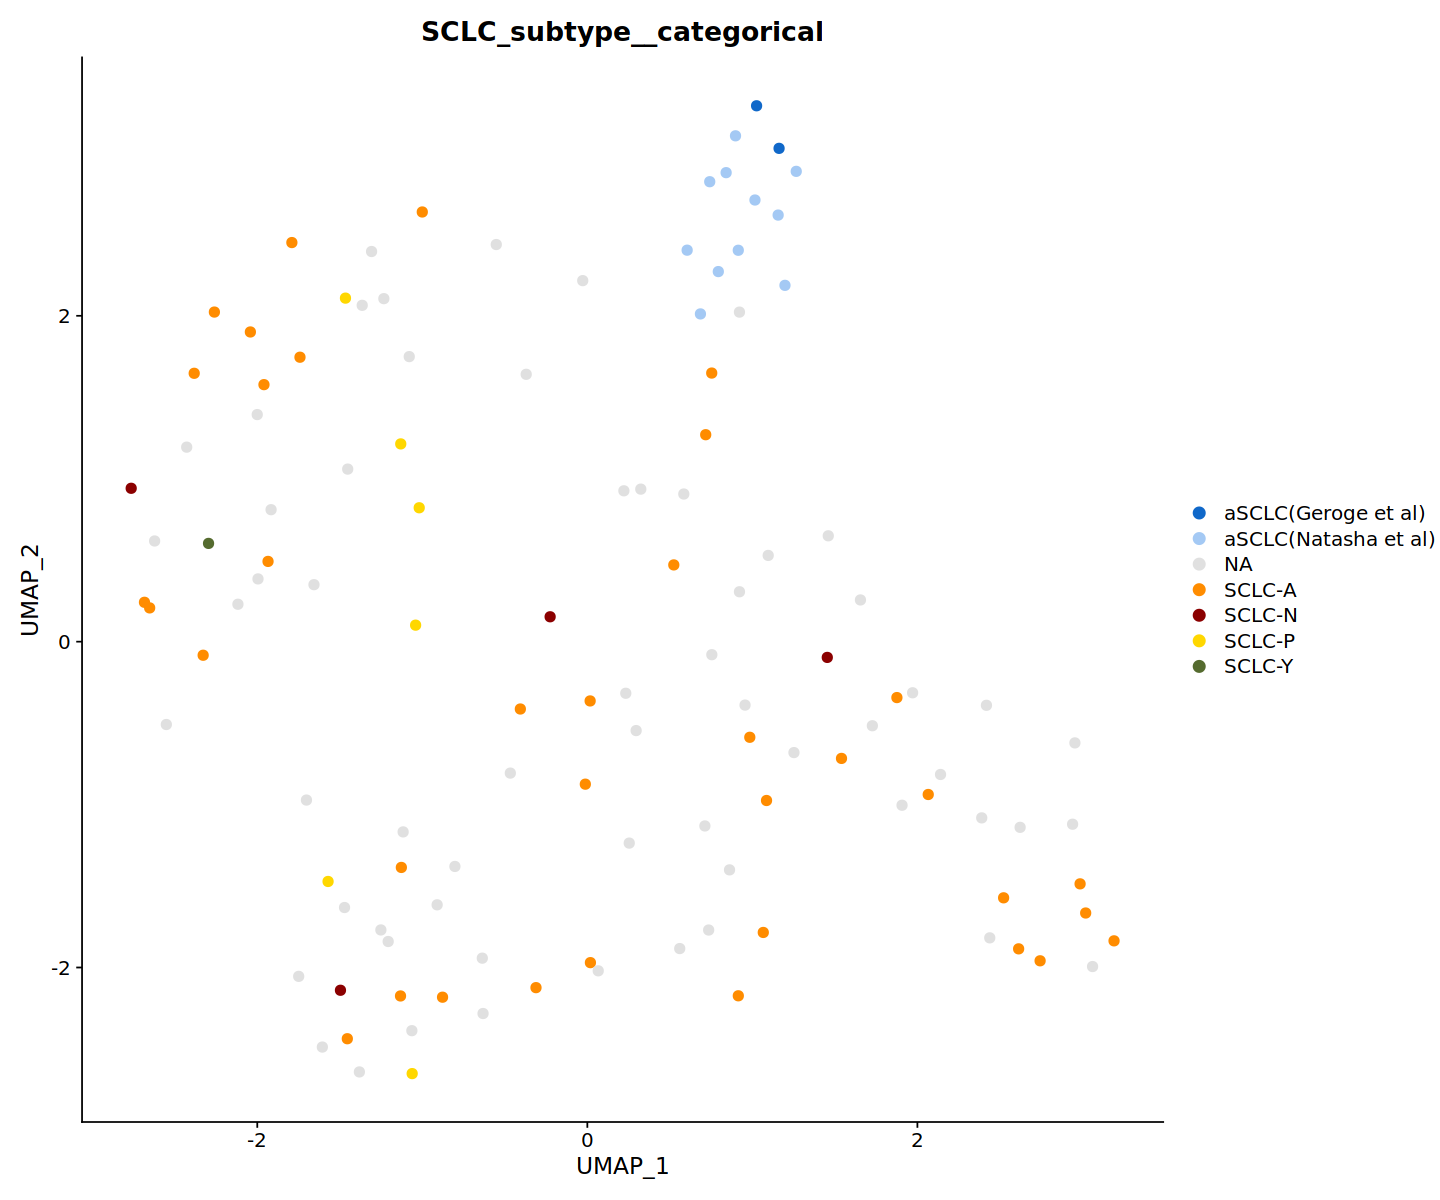

In [32]:
options(repr.plot.width = 12, repr.plot.height = 10)

p = DimPlot(srt.SCLC, reduction ="umap" , pt.size=2.5, 
                group.by = "SCLC_subtype__categorical", cols=c("#1068C9","#A4C9F4",
                                                               "#E0E0E0","#FF8C00", "#8B0000", "#FFD700", "#556B2F"))
p


# ggsave(
#   filename = "/hpc/users/leew17/Work/CellOrigin/Figure/UMAP_of_aSCLC_2.pdf",
#   plot = p,
#   width = 10,   # Set width of PDF
#   height = 10   # Set height of PDF
# )


In [34]:
library(dplyr)

# 1. UMAP 좌표 추출
umap_coords <- Embeddings(srt.SCLC, reduction = "umap") %>%
  as.data.frame() %>%
  tibble::rownames_to_column(var = "donor_id")  # barcode or cell name

# 2. Metadata에서 subtype 정보 가져오기
subtype_info <- srt.SCLC@meta.data %>%
  select(SCLC_subtype__categorical) %>%
  tibble::rownames_to_column(var = "donor_id")

# 3. 병합
umap_df <- left_join(umap_coords, subtype_info, by = "donor_id")

# 4. 확인
head(umap_df)

# 5. 저장 (선택)
# write.csv(umap_df, "UMAP_with_subtype.csv", row.names = FALSE)

,donor_id,UMAP_1,UMAP_2,SCLC_subtype__categorical
,<chr>,<dbl>,<dbl>,<chr>
1,S00830,-2.0002316,1.3937755,NA
2,S02378,1.0858065,-0.9749420,SCLC-A
3,S02299,-0.5517693,2.4374564,NA
4,S02219,0.8615493,-1.4006994,NA
5,S02328,-1.1269687,-1.3857768,SCLC-A
6,S02355,0.9218375,0.3062487,NA


In [37]:
umap_df[which(umap_df$SCLC_subtype__categorical=="NA"),"SCLC_subtype__categorical"]<-"Undefined"

In [38]:
table(umap_df$SCLC_subtype__categorical)


 aSCLC(Geroge et al) aSCLC(Natasha et al)               SCLC-A 
                   2                   11                   36 
              SCLC-N               SCLC-P               SCLC-Y 
                   4                    6                    1 
           Undefined 
                  60 

In [42]:
write.csv(umap_df,row.names=F,quote=F,
          file="./supplementary_files/umap.csv")

In [32]:
unique(combined_df$SCLC_subtype__categorical)

[1] "NA"     "SCLC-A" "SCLC-P" "SCLC-Y" "SCLC-N" "MSKCC"